# <b><i>What if we remove Final Blows?</i></b>

# <b>Raw Features</b>

## <b>Logistic Regression</b>

CS 422 Overwatch Simple Model

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, f1_score

Display stuff for easy edits

In [73]:
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Set up teams

In [74]:
df = pd.read_csv("Reduced_Stats.csv")

In [75]:
print(f"Original dataset shape: {df.shape}")
print(f"Expected number of games: {df.shape[0] // 10}")

Original dataset shape: (6110, 14)
Expected number of games: 611


In [76]:
features = [
    "Eliminations", "Damage Dealt", "Assists", "Objective Time",
    "Damage Mitigated", "Healing Done", "Deaths",
    "Solo Kills"
]

In [77]:
team_stats = df.groupby(
    ["match_id", "round_num", "team"]
)[features].sum().reset_index()

team_results = df.groupby(
    ["match_id", "round_num", "team"]
)["Result"].first().reset_index()

In [78]:
team_data_frame = team_stats.merge(
    team_results,
    on=["match_id", "round_num", "team"]
)

In [79]:
grouped = team_data_frame.groupby(["match_id", "round_num"])

In [80]:
X_rows = []
y_rows = []

for (match, round_), group in grouped:

    if len(group) != 2:
        continue

    t1 = group.iloc[0]
    t2 = group.iloc[1]

    diff = t1[features] - t2[features]

    X_rows.append(diff.values)
    y_rows.append(int(t1["Result"]))

In [81]:
X = pd.DataFrame(X_rows, columns=features)
y = pd.Series(y_rows)

Train/Split here

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scale

In [83]:
scaler = StandardScaler()

In [84]:
X_train = scaler.fit_transform(X_train)

In [85]:
X_test = scaler.transform(X_test)

Train

In [86]:
model = LogisticRegression(max_iter=5000)

In [87]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Predict

In [88]:
y_pred = model.predict(X_test)

Evaluation

MODEL PERFORMANCE (Logistic Regression)
Accuracy: 89.34%
F1 Score : 88.07%


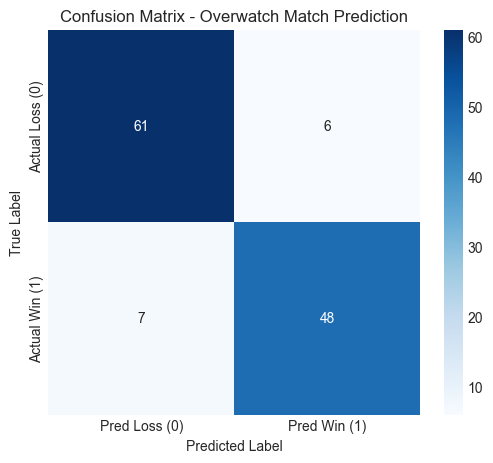

In [89]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# -------------------------
# Print metrics (clean format)
# -------------------------
print("="*50)
print("MODEL PERFORMANCE (Logistic Regression)")
print("="*50)
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")
print("="*50)

# -------------------------
# Confusion Matrix (Heatmap)
# -------------------------
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Loss (0)", "Pred Win (1)"],
    yticklabels=["Actual Loss (0)", "Actual Win (1)"]
)

plt.title("Confusion Matrix - Overwatch Match Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Coefficients

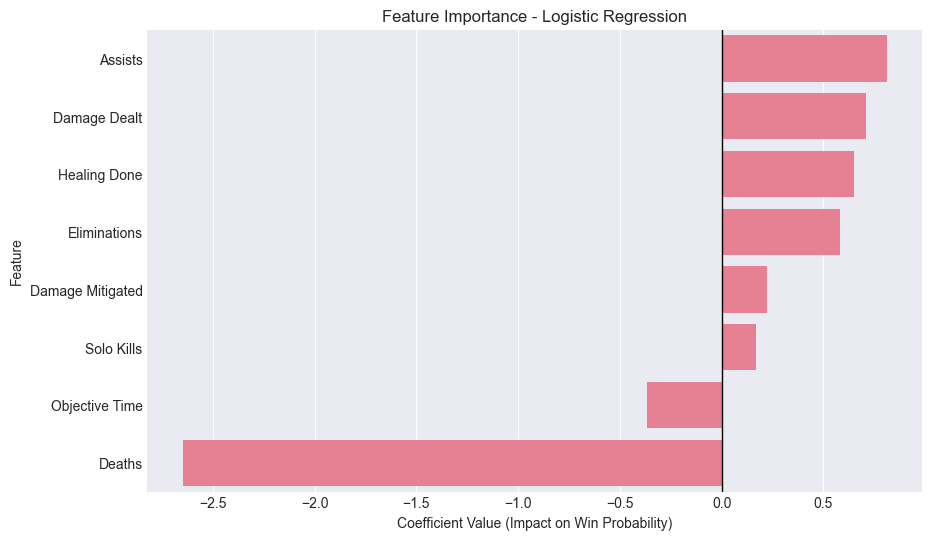

         Feature  Coefficient
         Assists     0.812885
    Damage Dealt     0.709619
    Healing Done     0.649575
    Eliminations     0.582257
Damage Mitigated     0.223176
      Solo Kills     0.167460
  Objective Time    -0.367056
          Deaths    -2.647758


In [90]:
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=coeffs
)

plt.title("Feature Importance - Logistic Regression")
plt.xlabel("Coefficient Value (Impact on Win Probability)")
plt.ylabel("Feature")

plt.axvline(0, color="black", linewidth=1)
plt.show()
print(coeffs.to_string(index=False))

In [91]:
scores = cross_val_score(model, X, y, cv=5, scoring="f1")
print("CV F1:", scores.mean())

CV F1: 0.916951116491185


## <b>Random Forest</b>

In [92]:
from sklearn.ensemble import RandomForestClassifier

In [93]:
tree_count = 500 # Tested 200 - 10,000 (for fun, I know 500 would probably be the upper bound at this point). Not much of a difference except for compute time.
tree_depth = 10

In [94]:
rf_model = RandomForestClassifier(
    n_estimators=tree_count,
    max_depth=tree_depth,
    random_state=42
)

In [95]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [96]:
rf_pred = rf_model.predict(X_test)

In [97]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

MODEL PERFORMANCE (Random Forest)
Accuracy: 92.62%
F1 Score : 91.59%


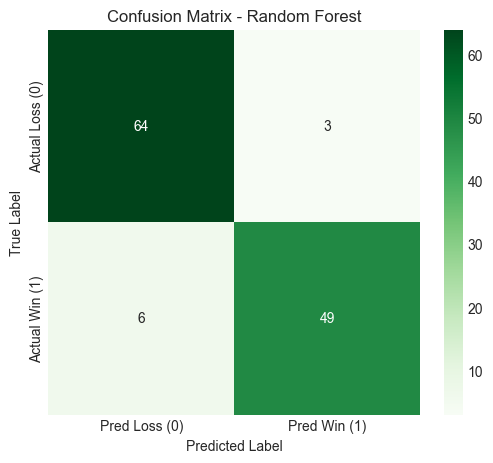

In [98]:
# -------------------------
# Print the stats cleanly
# -------------------------
print("="*50)
print("MODEL PERFORMANCE (Random Forest)")
print("="*50)
print(f"Accuracy: {rf_accuracy*100:.2f}%")
print(f"F1 Score : {rf_f1*100:.2f}%")
print("="*50)

# --------------------------------------------------
# Confusion Matrix (Heatmap again because it is cool)
# --------------------------------------------------

plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Pred Loss (0)", "Pred Win (1)"],
    yticklabels=["Actual Loss (0)", "Actual Win (1)"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

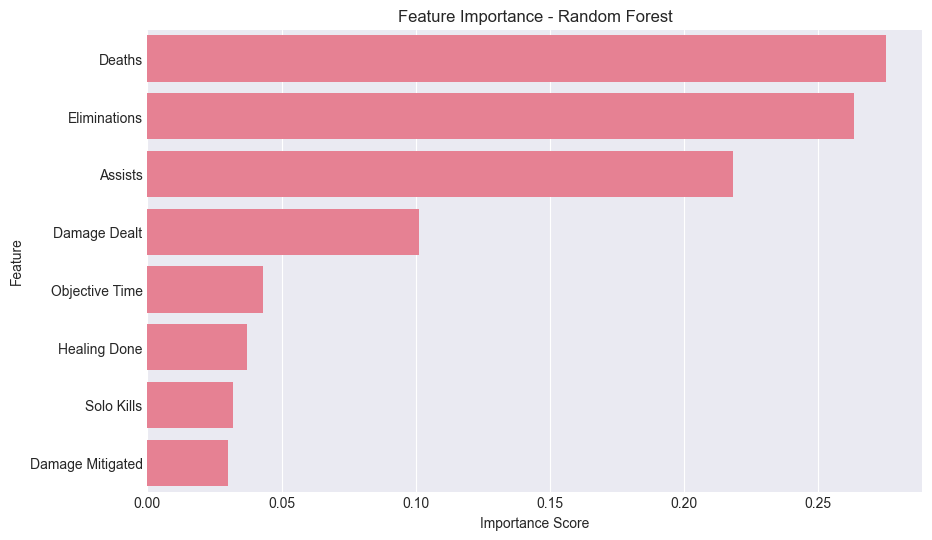

         Feature  Importance
          Deaths    0.275021
    Eliminations    0.263158
         Assists    0.218168
    Damage Dealt    0.101353
  Objective Time    0.042975
    Healing Done    0.037254
      Solo Kills    0.031998
Damage Mitigated    0.030074


In [99]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

print(importance.to_string(index=False))

In [100]:
rf_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Random Forest CV F1:", rf_scores.mean())

Random Forest CV F1: 0.9124418922614165


## <b>Gradient Boosting</b>

In [101]:
from sklearn.ensemble import GradientBoostingClassifier

In [102]:
tree_amount = 500 # 500-600 are better than 400 and 700
learn_rate = 0.05 # .05 is better than .1 and .01

In [103]:
gb_model = GradientBoostingClassifier(
    n_estimators=tree_amount,
    learning_rate=learn_rate,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [104]:
gb_pred = gb_model.predict(X_test)

In [105]:
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_cm = confusion_matrix(y_test, gb_pred)

MODEL PERFORMANCE (Gradient Boosting)
Accuracy: 93.44%
F1 Score : 92.59%


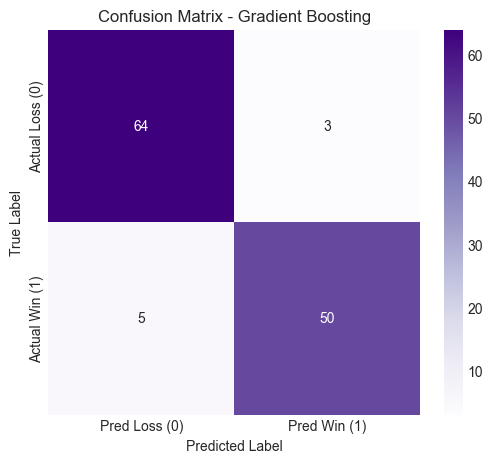

In [106]:
print("="*50)
print("MODEL PERFORMANCE (Gradient Boosting)")
print("="*50)
print(f"Accuracy: {gb_accuracy*100:.2f}%")
print(f"F1 Score : {gb_f1*100:.2f}%")
print("="*50)

plt.figure(figsize=(6,5))

sns.heatmap(
    gb_cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Pred Loss (0)", "Pred Win (1)"],
    yticklabels=["Actual Loss (0)", "Actual Win (1)"]
)

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

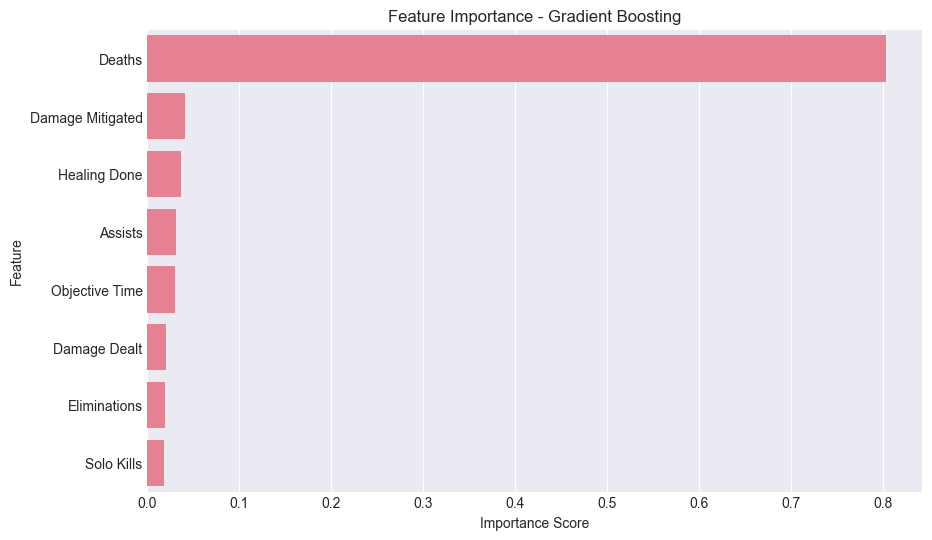

         Feature  Importance
          Deaths    0.802959
Damage Mitigated    0.041228
    Healing Done    0.037050
         Assists    0.030816
  Objective Time    0.030264
    Damage Dealt    0.020603
    Eliminations    0.018784
      Solo Kills    0.018296


In [107]:
gb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=gb_importance
)

plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

print(gb_importance.to_string(index=False))

In [108]:
gb_scores = cross_val_score(
    gb_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Gradient Boosting CV F1:", gb_scores.mean())

Gradient Boosting CV F1: 0.9127672327672327


# <b>Engineered Features</b>

## <b>Logistic Regression</b>

In [109]:
features_raw = [
    "Eliminations", "Damage Dealt", "Assists", "Objective Time",
    "Damage Mitigated", "Healing Done", "Deaths",
    "Solo Kills"
]

In [110]:
team_stats_raw = df.groupby(
    ["match_id", "round_num", "team"]
)[features_raw].sum().reset_index()

team_results_raw = df.groupby(
    ["match_id", "round_num", "team"]
)["Result"].first().reset_index()

In [111]:
team_data_frame = team_stats.merge(
    team_results,
    on=["match_id", "round_num", "team"]
)

In [112]:
team_data_frame["Deaths_safe"] = team_data_frame["Deaths"].replace(0, 1) # Avoid divide by 0

In [113]:
team_data_frame["KD"] = team_data_frame["Eliminations"] / team_data_frame["Deaths_safe"]
team_data_frame["Damage_per_Death"] = (team_data_frame["Damage Dealt"] / team_data_frame["Deaths_safe"])
team_data_frame["Assists_per_Death"] = (team_data_frame["Assists"] / team_data_frame["Deaths_safe"])
team_data_frame["Mitigated_per_Death"] = (team_data_frame["Damage Mitigated"] / team_data_frame["Deaths_safe"])
team_data_frame["Healing_per_Death"] = (team_data_frame["Healing Done"] / team_data_frame["Deaths_safe"])

I am keeping objective time and final blows

In [114]:
features = [
    "KD",
    "Damage_per_Death",
    "Assists_per_Death",
    "Mitigated_per_Death",
    "Healing_per_Death",
    "Objective Time"
]

In [115]:
team_data_frame["Result"] = team_data_frame["Result"].replace({5: 1})

grouped = team_data_frame.groupby(["match_id", "round_num"])

In [116]:
X_rows = []
y_rows = []

for (match, round_), group in grouped:

    if len(group) != 2:
        continue

    t1 = group.iloc[0]
    t2 = group.iloc[1]

    diff = t1[features] - t2[features]

    X_rows.append(diff.values)
    y_rows.append(int(t1["Result"]))

X = pd.DataFrame(X_rows, columns=features)
y = pd.Series(y_rows)

In [117]:
X = pd.DataFrame(X_rows, columns=features)
y = pd.Series(y_rows)

Train/Split

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [119]:
scaler = StandardScaler()

In [120]:
X_train = scaler.fit_transform(X_train)

In [121]:
X_test = scaler.transform(X_test)

In [122]:
model = LogisticRegression(max_iter=5000)

In [123]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [124]:
y_pred = model.predict(X_test)

MODEL PERFORMANCE (Logistic Regression)
Accuracy: 91.80%
F1 Score : 90.91%


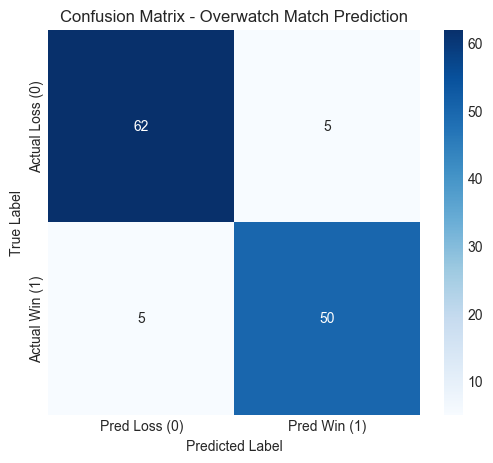

In [125]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# -------------------------
# Print metrics (clean format)
# -------------------------
print("="*50)
print("MODEL PERFORMANCE (Logistic Regression)")
print("="*50)
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")
print("="*50)

# -------------------------
# Confusion Matrix (Heatmap)
# -------------------------
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Loss (0)", "Pred Win (1)"],
    yticklabels=["Actual Loss (0)", "Actual Win (1)"]
)

plt.title("Confusion Matrix - Overwatch Match Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

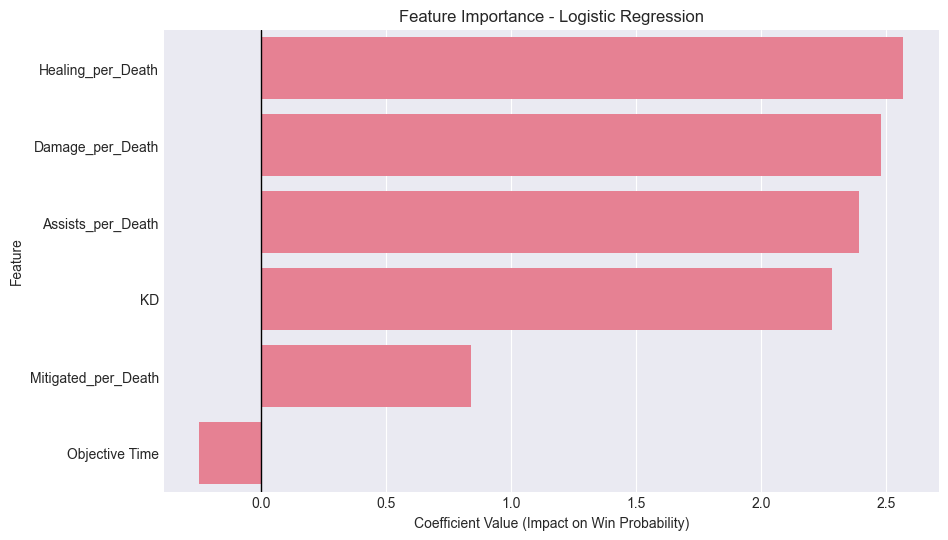

            Feature  Coefficient
  Healing_per_Death     2.568556
   Damage_per_Death     2.476879
  Assists_per_Death     2.389467
                 KD     2.281106
Mitigated_per_Death     0.839568
     Objective Time    -0.248862


In [126]:
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=coeffs
)

plt.title("Feature Importance - Logistic Regression")
plt.xlabel("Coefficient Value (Impact on Win Probability)")
plt.ylabel("Feature")

plt.axvline(0, color="black", linewidth=1)
plt.show()
print(coeffs.to_string(index=False))

In [127]:
scores = cross_val_score(model, X, y, cv=5, scoring="f1")
print("CV F1:", scores.mean())

CV F1: 0.9150871953437335


## <b>Random Forest</b>

In [128]:
tree_count = 500 # Tested 200 - 10,000 (for fun, I know 500 would probably be the upper bound at this point). Not much of a difference except for compute time.
tree_depth = 10

In [129]:
rf_model = RandomForestClassifier(
    n_estimators=tree_count,
    max_depth=tree_depth,
    random_state=42
)

In [130]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [131]:
rf_pred = rf_model.predict(X_test)

In [132]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

MODEL PERFORMANCE (Random Forest)
Accuracy: 90.16%
F1 Score : 89.29%


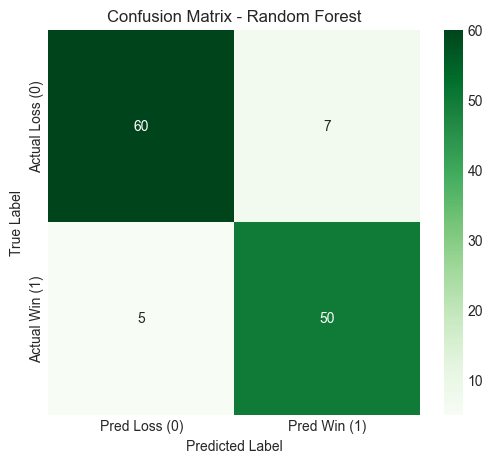

In [133]:
# -------------------------
# Print the stats cleanly
# -------------------------
print("="*50)
print("MODEL PERFORMANCE (Random Forest)")
print("="*50)
print(f"Accuracy: {rf_accuracy*100:.2f}%")
print(f"F1 Score : {rf_f1*100:.2f}%")
print("="*50)

# --------------------------------------------------
# Confusion Matrix (Heatmap again because it is cool)
# --------------------------------------------------

plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Pred Loss (0)", "Pred Win (1)"],
    yticklabels=["Actual Loss (0)", "Actual Win (1)"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

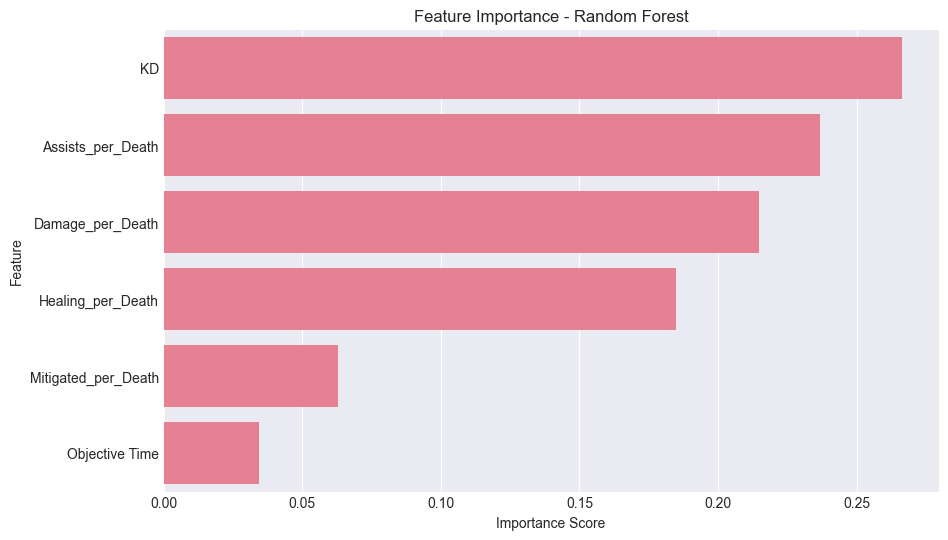

            Feature  Importance
                 KD    0.266298
  Assists_per_Death    0.236679
   Damage_per_Death    0.214929
  Healing_per_Death    0.184894
Mitigated_per_Death    0.062720
     Objective Time    0.034480


In [134]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

print(importance.to_string(index=False))

In [135]:
rf_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Random Forest CV F1:", rf_scores.mean())

Random Forest CV F1: 0.9176432618341785


## <b>Gradient Boosting</b>

In [136]:
tree_amount = 1000 # Bests From Tests
learn_rate = 0.1 # Bests From Tests

In [137]:
gb_model = GradientBoostingClassifier(
    n_estimators=tree_amount,
    learning_rate=learn_rate,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",1000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [138]:
gb_pred = gb_model.predict(X_test)

In [139]:
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_cm = confusion_matrix(y_test, gb_pred)

MODEL PERFORMANCE (Gradient Boosting)
Accuracy: 93.44%
F1 Score : 92.73%


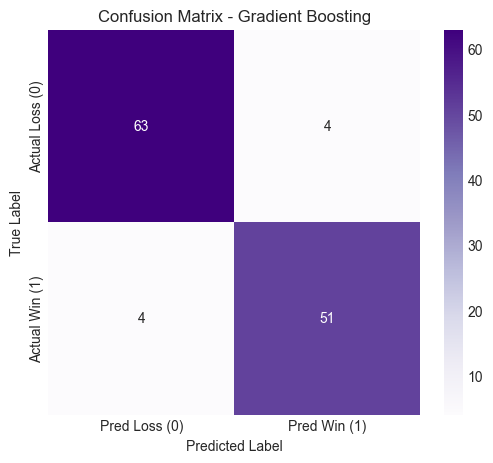

In [140]:
print("="*50)
print("MODEL PERFORMANCE (Gradient Boosting)")
print("="*50)
print(f"Accuracy: {gb_accuracy*100:.2f}%")
print(f"F1 Score : {gb_f1*100:.2f}%")
print("="*50)

plt.figure(figsize=(6,5))

sns.heatmap(
    gb_cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Pred Loss (0)", "Pred Win (1)"],
    yticklabels=["Actual Loss (0)", "Actual Win (1)"]
)

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

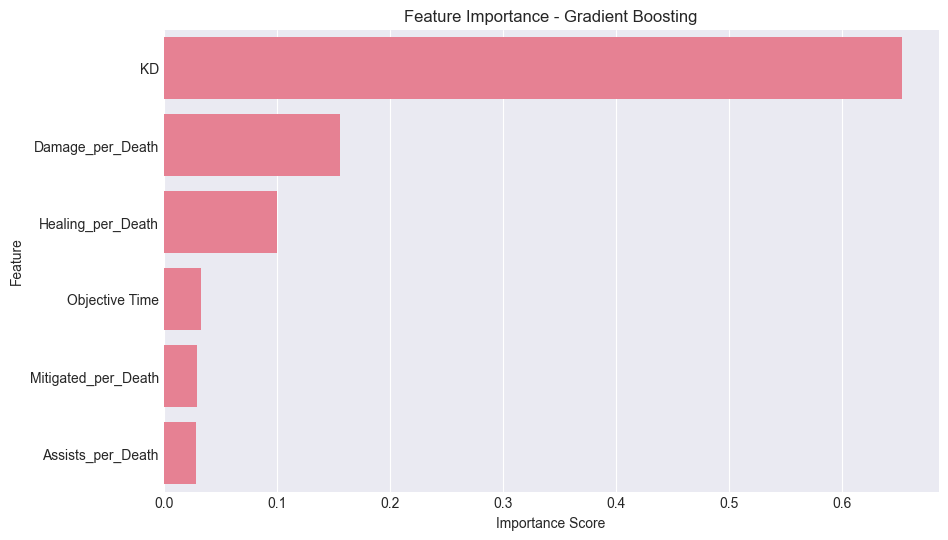

            Feature  Importance
                 KD    0.652611
   Damage_per_Death    0.156099
  Healing_per_Death    0.100034
     Objective Time    0.033430
Mitigated_per_Death    0.029555
  Assists_per_Death    0.028272


In [141]:
gb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=gb_importance
)

plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

print(gb_importance.to_string(index=False))

In [142]:
gb_scores = cross_val_score(
    gb_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Gradient Boosting CV F1:", gb_scores.mean())

Gradient Boosting CV F1: 0.9105676231767614


# <b>Conclusion</b>

##### No Final Blows
|Model|Feature Set|Accuracy|F1 Score|Cross-Validation F1|
|---|---|---|---|---|
|Logistic Regression|Raw|89.34%|88.07%|91.70%|
|Logistic Regression|Engineered|91.80%|90.91%|91.51%|
|Random Forest|Raw|92.62%|91.59%|91.24%|
|Random Forest|Engineered|90.16%|89.29%|91.76%|
|Gradient Boosting|Raw|93.44%|92.59%|91.28%|
|Gradient Boosting|Engineered|93.44%|92.73%|91.06%|

##### Original, With Final Blows
|Model|Feature Set|Accuracy|F1 Score|Cross-Validation F1|
|---|---|---|---|---|
|Logistic Regression|Raw|89.34%|88.29%|92.01%|
|Logistic Regression|Engineered|91.80%|90.91%|91.04%|
|Random Forest|Raw|91.80%|90.74%|92.12%|
|Random Forest|Engineered|90.98%|89.91%|92.12%|
|Gradient Boosting|Raw|94.26%|93.46%|92.24%|
|Gradient Boosting|Engineered|94.26%|93.46%|90.91%|